# Лабораторная работа 4.4

Приближение функции в пространстве $L_{2}(w)$ на отрезке $[-1, 1]$. Полное условие [здесь](function_approximation.md).

## Теоретическая часть

Взвешенное скалярное произведение функций $u$ и $v$ задается формулой

$$
\langle u, v \rangle_w = \int_{-1}^{1} u(x) v(x) w(x)\,dx,
$$

где $w(x) > 0$ на всем отрезке. Тогда норма в пространстве $L_2(w)$ имеет вид

$$
\|u\|_{L_2(w)} = \sqrt{\langle u, u \rangle_w}.
$$

Ищем аппроксимант в виде

$$
p_n(x) = \sum_{k=1}^{n} c_k \phi_k(x),
$$

который минимизирует величину $\|f - p_n\|_{L_2(w)}$.

Необходимое и достаточное условие минимума для линейного подпространства состоит в ортогональности ошибки всем базисным функциям:

$$
\langle f - p_n, \phi_j \rangle_w = 0, \quad j = 1, \dots, n.
$$

После подстановки разложения для $p_n$ получаем систему нормальных уравнений

$$
\sum_{k=1}^{n} c_k \langle \phi_k, \phi_j \rangle_w = \langle f, \phi_j \rangle_w,
\quad j = 1, \dots, n.
$$

В матричной форме это система

$$
G c = d,
$$

где $G_{jk} = \langle \phi_k, \phi_j \rangle_w$ — матрица Грама, а $d_j = \langle f, \phi_j \rangle_w$. В работе ниже все скалярные произведения вычисляются с помощью `scipy.integrate.quad`, после чего система решается стандартными средствами линейной алгебры.

In [2]:
import math
import os
from collections.abc import Callable, Sequence
from dataclasses import dataclass

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad


np.set_printoptions(precision=6, suppress=True)

ScalarFunction = Callable[[float], float]


@dataclass(frozen=True)
class BasisFunctionSet:
    """Описывает набор базисных функций для аппроксимации."""

    name: str
    labels: tuple[str, ...]
    functions: tuple[ScalarFunction, ...]


@dataclass(frozen=True)
class WeightedApproximationResult:
    """Хранит результат решения системы Грама."""

    coefficients: np.ndarray
    gram_matrix: np.ndarray
    rhs: np.ndarray


def evaluate_scalar_function_on_grid(
    function: ScalarFunction,
    x_values: np.ndarray,
) -> np.ndarray:
    """Вычисляет значения скалярной функции на произвольной сетке."""
    x_array = np.asarray(x_values, dtype=float)
    flattened_points = x_array.reshape(-1)
    flattened_values = np.array(
        [function(float(point)) for point in flattened_points],
        dtype=float,
    )
    return flattened_values.reshape(x_array.shape)


def validate_weighted_approximation_input(
    function: ScalarFunction,
    weight_function: ScalarFunction,
    basis_functions: Sequence[ScalarFunction],
    interval: tuple[float, float],
) -> tuple[tuple[ScalarFunction, ...], tuple[float, float]]:
    """Проверяет корректность входных данных задачи приближения."""
    if not callable(function):
        raise TypeError("f должна быть вызываемой функцией.")
    if not callable(weight_function):
        raise TypeError("w должна быть вызываемой функцией.")

    basis_functions_tuple = tuple(basis_functions)
    if not basis_functions_tuple:
        raise ValueError("Набор базисных функций не должен быть пустым.")
    if any(not callable(basis_function) for basis_function in basis_functions_tuple):
        raise TypeError("Каждый элемент базиса должен быть вызываемой функцией.")

    left_endpoint, right_endpoint = map(float, interval)
    if left_endpoint >= right_endpoint:
        raise ValueError("Левая граница интервала должна быть меньше правой.")

    control_grid = np.linspace(left_endpoint, right_endpoint, 401)
    weight_values = evaluate_scalar_function_on_grid(
        weight_function,
        control_grid,
    )
    if np.any(weight_values <= 0.0):
        raise ValueError("Весовая функция должна быть положительной на всем отрезке.")

    return basis_functions_tuple, (left_endpoint, right_endpoint)


def compute_weighted_inner_product(
    lhs_function: ScalarFunction,
    rhs_function: ScalarFunction,
    weight_function: ScalarFunction,
    interval: tuple[float, float],
    absolute_tolerance: float = 1e-10,
    relative_tolerance: float = 1e-10,
) -> float:
    """Вычисляет взвешенное скалярное произведение двух функций."""
    left_endpoint, right_endpoint = interval
    integral_value, _ = quad(
        lambda x: weight_function(x) * lhs_function(x) * rhs_function(x),
        left_endpoint,
        right_endpoint,
        epsabs=absolute_tolerance,
        epsrel=relative_tolerance,
        limit=200,
    )
    return float(integral_value)


def compute_best_weighted_L2_approximation_coefficients(
    function: ScalarFunction,
    weight_function: ScalarFunction,
    basis_functions: Sequence[ScalarFunction],
    interval: tuple[float, float] = (-1.0, 1.0),
) -> WeightedApproximationResult:
    """Находит коэффициенты наилучшего приближения в пространстве L2(w)."""
    basis_functions_tuple, validated_interval = validate_weighted_approximation_input(
        function,
        weight_function,
        basis_functions,
        interval,
    )
    basis_function_count = len(basis_functions_tuple)
    gram_matrix = np.zeros(
        (basis_function_count, basis_function_count),
        dtype=float,
    )
    rhs = np.zeros(basis_function_count, dtype=float)

    for row_index in range(basis_function_count):
        rhs[row_index] = compute_weighted_inner_product(
            function,
            basis_functions_tuple[row_index],
            weight_function,
            validated_interval,
        )
        for column_index in range(row_index, basis_function_count):
            gram_value = compute_weighted_inner_product(
                basis_functions_tuple[row_index],
                basis_functions_tuple[column_index],
                weight_function,
                validated_interval,
            )
            gram_matrix[row_index, column_index] = gram_value
            # матрица грамма симметрична => вычисляем только верхний треугольник
            gram_matrix[column_index, row_index] = gram_value

    coefficients = np.linalg.solve(gram_matrix, rhs)
    return WeightedApproximationResult(
        coefficients=coefficients,
        gram_matrix=gram_matrix,
        rhs=rhs,
    )


def create_linear_combination_function(
    coefficients: np.ndarray,
    basis_functions: Sequence[ScalarFunction],
) -> ScalarFunction:
    """Строит функцию по ее коэффициентам и базисным функциям."""
    coefficients_array = np.asarray(coefficients, dtype=float)
    basis_functions_tuple = tuple(basis_functions)
    if coefficients_array.ndim != 1:
        raise ValueError("Коэффициенты должны быть одномерным массивом.")
    if coefficients_array.size != len(basis_functions_tuple):
        raise ValueError("Число коэффициентов должно совпадать с размером базиса.")

    def linear_combination(x: float) -> float:
        result = 0.0
        for coefficient, basis_function in zip(
            coefficients_array,
            basis_functions_tuple,
        ):
            result += float(coefficient) * float(basis_function(x))
        return result

    return linear_combination


def evaluate_linear_combination(
    coefficients: np.ndarray,
    basis_functions: Sequence[ScalarFunction],
    x_values: np.ndarray,
) -> np.ndarray:
    """Вычисляет значения линейной комбинации на заданной сетке."""
    approximation_function = create_linear_combination_function(
        coefficients,
        basis_functions,
    )
    return evaluate_scalar_function_on_grid(
        approximation_function,
        x_values,
    )


def compute_weighted_L2_error_norm(
    function: ScalarFunction,
    approximation_function: ScalarFunction,
    weight_function: ScalarFunction,
    interval: tuple[float, float] = (-1.0, 1.0),
) -> float:
    """Вычисляет норму ошибки приближения в пространстве L2(w)."""

    def approximation_error(x: float) -> float:
        return function(x) - approximation_function(x)

    squared_norm = compute_weighted_inner_product(
        approximation_error,
        approximation_error,
        weight_function,
        interval,
    )
    return math.sqrt(max(squared_norm, 0.0))


def compute_maximum_absolute_error(
    function_values: np.ndarray,
    approximation_values: np.ndarray,
) -> float:
    """Вычисляет максимальную абсолютную ошибку на подробной сетке."""
    return float(
        np.max(
            np.abs(
                np.asarray(function_values, dtype=float)
                - np.asarray(approximation_values, dtype=float)
            )
        )
    )


def create_power_function(power: int) -> ScalarFunction:
    """Создает степенную функцию x^power."""
    if power < 0:
        raise ValueError("Степень должна быть неотрицательной.")
    return lambda x, power=power: x**power


def plot_function_and_approximation(
    x_grid: np.ndarray,
    function_values: np.ndarray,
    approximation_values: np.ndarray,
    title: str,
) -> None:
    """Строит графики исходной функции и ее приближения."""
    plt.figure(figsize=(10, 6))
    plt.plot(
        x_grid,
        function_values,
        linewidth=2.4,
        label="f(x)",
    )
    plt.plot(
        x_grid,
        approximation_values,
        linestyle="--",
        linewidth=2.2,
        label="Приближение",
    )
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_approximation_error(
    x_grid: np.ndarray,
    error_values: np.ndarray,
    title: str,
) -> None:
    """Строит график разности между функцией и приближением."""
    plt.figure(figsize=(10, 4.5))
    plt.plot(
        x_grid,
        error_values,
        color="crimson",
        linewidth=2.0,
    )
    plt.axhline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=1.0,
    )
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("f(x) - p_n(x)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def print_basis_coefficients(
    basis_labels: Sequence[str],
    coefficients: np.ndarray,
) -> None:
    """Печатает коэффициенты приближения в удобном виде."""
    for basis_label, coefficient in zip(basis_labels, coefficients):
        print(f"  {basis_label:>10}: {coefficient: .6f}")


def run_weighted_approximation_experiment(
    function: ScalarFunction,
    weight_function: ScalarFunction,
    basis_set: BasisFunctionSet,
    x_grid: np.ndarray,
    interval: tuple[float, float] = (-1.0, 1.0),
) -> dict[str, float]:
    """Проводит полный эксперимент для выбранного набора базисных функций."""
    approximation_result = compute_best_weighted_L2_approximation_coefficients(
        function,
        weight_function,
        basis_set.functions,
        interval,
    )
    approximation_function = create_linear_combination_function(
        approximation_result.coefficients,
        basis_set.functions,
    )
    function_values = evaluate_scalar_function_on_grid(
        function,
        x_grid,
    )
    approximation_values = evaluate_linear_combination(
        approximation_result.coefficients,
        basis_set.functions,
        x_grid,
    )
    error_values = function_values - approximation_values

    weighted_l2_error_norm = compute_weighted_L2_error_norm(
        function,
        approximation_function,
        weight_function,
        interval,
    )
    maximum_absolute_error = compute_maximum_absolute_error(
        function_values,
        approximation_values,
    )
    gram_condition_number = float(np.linalg.cond(approximation_result.gram_matrix))

    print(basis_set.name)
    print("Коэффициенты c_k:")
    print_basis_coefficients(
        basis_set.labels,
        approximation_result.coefficients,
    )
    print("Число обусловленности матрицы Грама = " f"{gram_condition_number:.6e}")
    print("Ошибка ||f - p_n||_L2(w) = " f"{weighted_l2_error_norm:.6e}")
    print("Максимальная ошибка на подробной сетке = " f"{maximum_absolute_error:.6e}")
    print()

    plot_function_and_approximation(
        x_grid,
        function_values,
        approximation_values,
        title=("Функция и L2(w)-приближение: " f"{basis_set.name}"),
    )
    plot_approximation_error(
        x_grid,
        error_values,
        title=("Разность f(x) - p_n(x): " f"{basis_set.name}"),
    )

    return {
        "weighted_l2_error_norm": weighted_l2_error_norm,
        "maximum_absolute_error": maximum_absolute_error,
        "gram_condition_number": gram_condition_number,
    }

## Экспериментальная часть

В качестве теста выбраны

$$
f(x) = e^x + 0.4 \sin(3x), \qquad w(x) = e^x.
$$

Сравним два набора базисных функций:

- полиномиальный базис $\{1, x, x^2, x^3, x^4\}$;
- смешанный полиномиально-тригонометрический базис $\{1, x, x^2, \sin(\pi x), \cos(\pi x), \sin(2 \pi x)\}$.

Тестовая функция: f(x) = exp(x) + 0.4 * sin(3 x)
Весовая функция: w(x) = exp(x)

Полиномиальный базис {1, x, x^2, x^3, x^4}
Коэффициенты c_k:
           1:  1.011972
           x:  2.062345
         x^2:  0.376327
         x^3: -0.906666
         x^4:  0.188971
Число обусловленности матрицы Грама = 5.322440e+02
Ошибка ||f - p_n||_L2(w) = 3.108405e-02
Максимальная ошибка на подробной сетке = 1.101589e-01



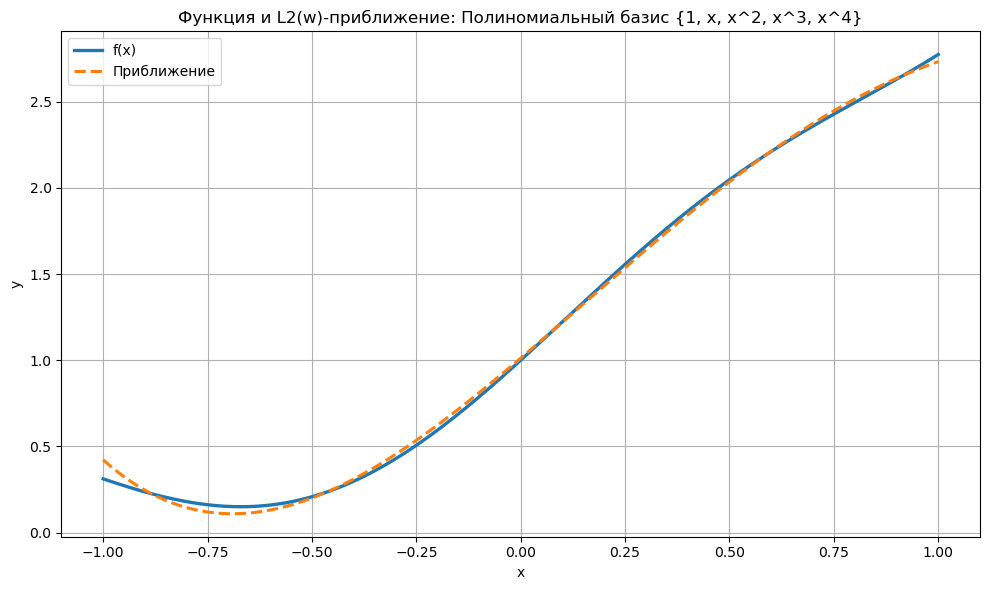

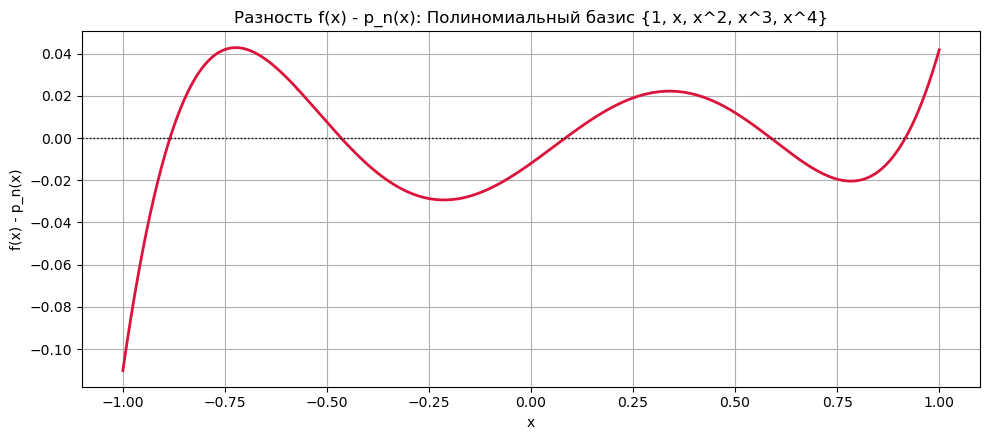

Смешанный базис {1, x, x^2, sin(pi x), cos(pi x), sin(2 pi x)}
Коэффициенты c_k:
           1:  0.982957
           x:  1.228698
         x^2:  0.576738
   sin(pi x):  0.305007
   cos(pi x):  0.017511
  sin(2 pi x):  0.003182
Число обусловленности матрицы Грама = 4.780245e+02
Ошибка ||f - p_n||_L2(w) = 1.525260e-03
Максимальная ошибка на подробной сетке = 3.848021e-03



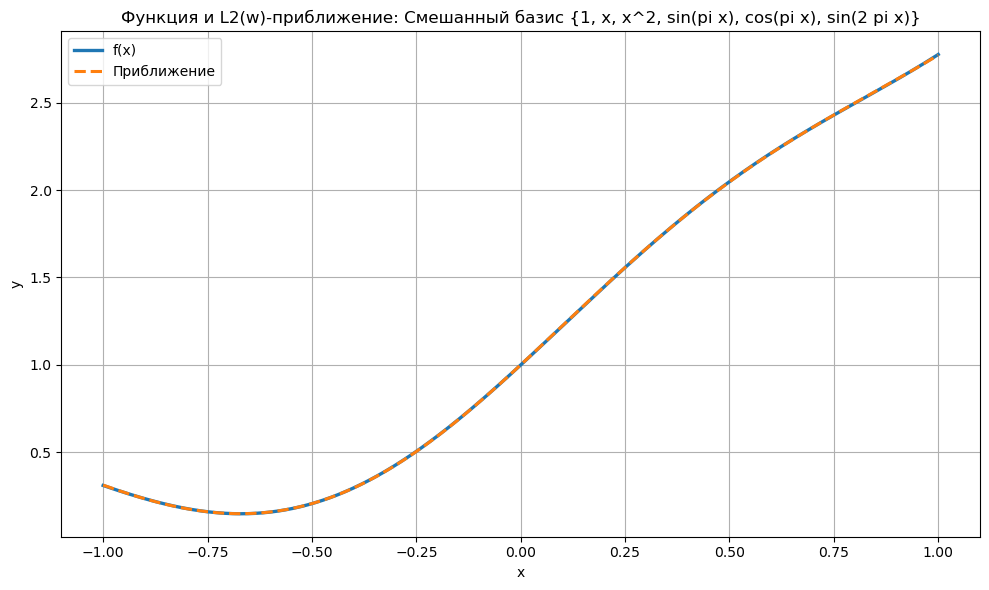

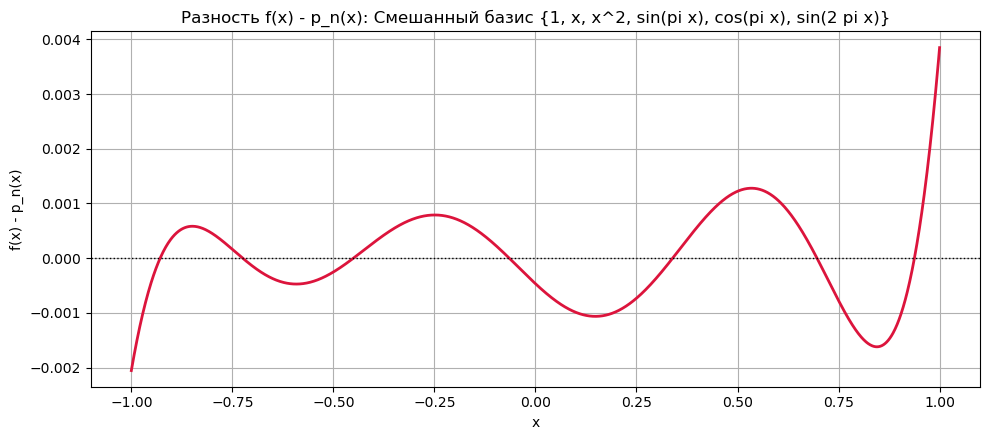

Сводка по экспериментам
Полиномиальный базис {1, x, x^2, x^3, x^4}
||f - p_n||_L2(w) = 3.108405e-02
max|f - p_n| = 1.101589e-01
cond(G) = 5.322440e+02
Смешанный базис {1, x, x^2, sin(pi x), cos(pi x), sin(2 pi x)}
||f - p_n||_L2(w) = 1.525260e-03
max|f - p_n| = 3.848021e-03
cond(G) = 4.780245e+02


In [3]:
def target_function(x: float) -> float:
    """Тестовая функция для задачи приближения."""
    return math.exp(x) + 0.4 * math.sin(3.0 * x)


def weight_function(x: float) -> float:
    """Положительная весовая функция на [-1, 1]."""
    return math.exp(x)


polynomial_basis_set = BasisFunctionSet(
    name="Полиномиальный базис {1, x, x^2, x^3, x^4}",
    labels=("1", "x", "x^2", "x^3", "x^4"),
    functions=tuple(create_power_function(power) for power in range(5)),
)
mixed_basis_set = BasisFunctionSet(
    name=("Смешанный базис " "{1, x, x^2, sin(pi x), cos(pi x), sin(2 pi x)}"),
    labels=(
        "1",
        "x",
        "x^2",
        "sin(pi x)",
        "cos(pi x)",
        "sin(2 pi x)",
    ),
    functions=(
        create_power_function(0),
        create_power_function(1),
        create_power_function(2),
        lambda x: math.sin(math.pi * x),
        lambda x: math.cos(math.pi * x),
        lambda x: math.sin(2.0 * math.pi * x),
    ),
)

basis_sets = (
    polynomial_basis_set,
    mixed_basis_set,
)
dense_grid = np.linspace(-1.0, 1.0, 2001)

print("Тестовая функция: f(x) = exp(x) + 0.4 * sin(3 x)")
print("Весовая функция: w(x) = exp(x)")
print()

experiment_summary: dict[str, dict[str, float]] = {}

for basis_set in basis_sets:
    experiment_summary[basis_set.name] = run_weighted_approximation_experiment(
        target_function,
        weight_function,
        basis_set,
        dense_grid,
    )

print("Сводка по экспериментам")
for basis_name, metrics in experiment_summary.items():
    print(basis_name)
    print("||f - p_n||_L2(w) = " f"{metrics['weighted_l2_error_norm']:.6e}")
    print("max|f - p_n| = " f"{metrics['maximum_absolute_error']:.6e}")
    print("cond(G) = " f"{metrics['gram_condition_number']:.6e}")

## Вывод

Реализация сводит задачу наилучшего приближения в $L_2(w)$ к решению системы с матрицей Грама, элементы которой вычисляются численным интегрированием. Для выбранной функции $f(x) = e^x + 0.4 \sin(3x)$ смешанный базис оказывается точнее чисто полиномиального: он лучше описывает осциллирующую составляющую и потому дает меньшую ошибку как в норме $L_2(w)$, так и на подробной сетке. Вес $w(x) = e^x$ усиливает вклад правой части отрезка, поэтому качество аппроксимации вблизи $x = 1$ влияет на итоговый результат сильнее, чем вблизи $x = -1$.